In [ ]:
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from torch import nn
import torch
import time
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from datetime import datetime
import copy
import random

import logging

logging.getLogger("kedro.io").setLevel(logging.WARNING)


def debug(msg):
    print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] {msg}")


class BrushlessMotor(Dataset):
    def __init__(self, time_series_partitions, df_splitted_path, split="train"):
        self.time_series_partitions = time_series_partitions
        self.time_series_data = catalog.load(self.time_series_partitions)
        self.df_splitted_path = df_splitted_path
        self.df = catalog.load(df_splitted_path)
        self.split = split

        columns = ["anomaly_label", "ism330dhcx_acc", "domain_shift_op", "split"]
        self.df = self.df[columns].copy()

        labels = self.df["anomaly_label"].unique()
        self.label_map = {label: idx for idx, label in enumerate(labels)}
        self.df["label_idx"] = self.df["anomaly_label"].map(self.label_map)

        df_train = self.df[self.df["split"] == "train"]
        df_val = self.df[self.df["split"] == "val"]
        df_test = self.df[self.df["split"] == "test"]

        if self.split == "train":
            self.df = df_train.reset_index(drop=True)
        elif self.split == "val":
            self.df = df_val.reset_index(drop=True)
        elif self.split == "test":
            self.df = df_test.reset_index(drop=True)
        else:
            raise ValueError("The 'split' argument must be 'train', 'val' or 'test'.")

    def __len__(self):
        return self.df.shape[0]

    def __getitem__(self, idx):
        file_name = self.df.loc[idx, "ism330dhcx_acc"]
        # Nota: O Kedro às vezes remove a extensão do nome na chave do dicionário.
        # Se der erro de chave (KeyError), altera a linha acima para:
        # file_name = self.df.loc[idx, "ism330dhcx_acc"].replace(".parquet", "")

        label = self.df.loc[idx, "label_idx"]
        ts_df = self.time_series_data[file_name]()
        ts = ts_df[["A_x [g]", "A_y [g]", "A_z [g]"]].values
        ts = ts[:37101, :].astype(np.float32)
        return ts, label


class Simple1DCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # PyTorch Conv1d expects input in the format (Batch, Channels, Length)
        # Our target_length is 37101 with 3 channels (A_x, A_y, A_z)
        self.conv1 = nn.Conv1d(
            in_channels=3, out_channels=16, kernel_size=7, stride=2, padding=3
        )
        self.pool1 = nn.MaxPool1d(kernel_size=4, stride=4)

        self.conv2 = nn.Conv1d(
            in_channels=16, out_channels=32, kernel_size=5, stride=2, padding=2
        )
        self.pool2 = nn.MaxPool1d(kernel_size=4, stride=4)

        # AdaptiveAvgPool1d converts variable lengths to 1, facilitating the Linear layer
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(32, num_classes)

    def forward(self, x):
        # Transpose from (Batch, Length, Channels) to (Batch, Channels, Length)
        x = x.permute(0, 2, 1)

        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = self.pool2(x)

        x = self.global_pool(x)  # Format: (Batch, 32, 1)
        x = x.squeeze(-1)  # Format: (Batch, 32)
        x = self.fc(x)  # Format: (Batch, num_classes)
        return x

[2026-08-08 15:32:05] Using device: cpu
[2026-08-08 15:32:05] Loading datasets
[2026-08-08 15:32:06] Class mapping: {'belt': 0, 'magnetic': 1, 'normal': 2}
[2026-08-08 15:32:06] Building model
[2026-08-08 15:32:06] Starting training
[2026-08-08 15:32:09] New best val loss: 1.0640 (Model saved)
[2026-08-08 15:32:09] New best train loss: 1.0660
Epoch 001 | train loss 1.0660 | train acc 0.4495 | val loss 1.0640 | val acc 0.4839 | time 2.95s
[2026-08-08 15:32:10] New best val loss: 1.0554 (Model saved)
[2026-08-08 15:32:10] New best train loss: 1.0546
Epoch 002 | train loss 1.0546 | train acc 0.5000 | val loss 1.0554 | val acc 0.4839 | time 1.59s
[2026-08-08 15:32:12] New best val loss: 1.0360 (Model saved)
[2026-08-08 15:32:12] New best train loss: 1.0482
Epoch 003 | train loss 1.0482 | train acc 0.5000 | val loss 1.0360 | val acc 0.4839 | time 1.55s
[2026-08-08 15:32:13] New best val loss: 0.9979 (Model saved)
[2026-08-08 15:32:13] New best train loss: 1.0273
Epoch 004 | train loss 1.027

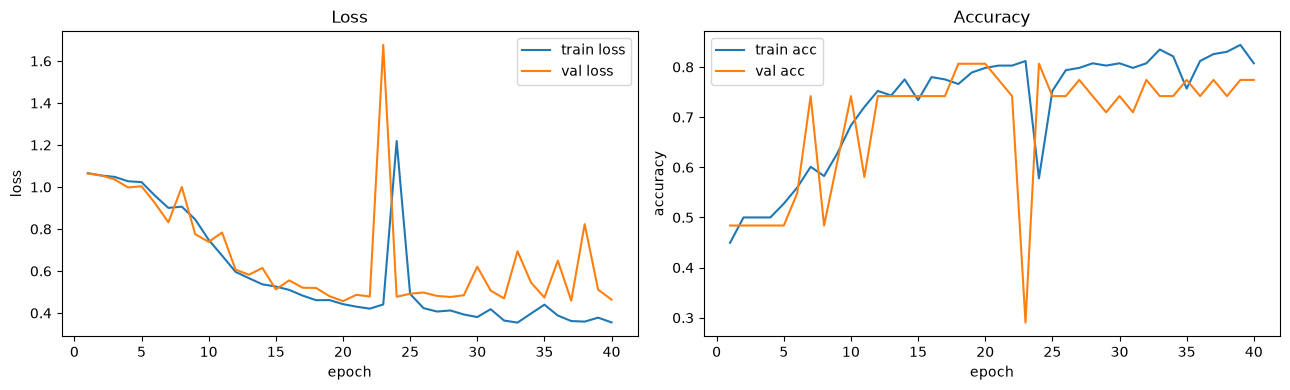

In [7]:
# =====================================================================
# MAIN SCRIPT
# =====================================================================


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


BATCH_SIZE = 16
LR = 1e-2
NUM_EPOCHS = 50
PATIENCE = 7
NUM_CLASSES = 3
NUM_WORKERS = 0
RANDOM_STATE = 42
DF_SPLITTED_PATH = "df_splitted"
TIME_SERIES_DATA_PATH = "time_series_folder"

set_seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
debug(f"Using device: {device}")

debug("Loading datasets")

ds_train = BrushlessMotor(TIME_SERIES_DATA_PATH, DF_SPLITTED_PATH, split="train")
ds_val = BrushlessMotor(TIME_SERIES_DATA_PATH, DF_SPLITTED_PATH, split="val")
ds_test = BrushlessMotor(TIME_SERIES_DATA_PATH, DF_SPLITTED_PATH, split="test")

# Get target names for the classification report
target_names = [
    name for name, idx in sorted(ds_train.label_map.items(), key=lambda item: item[1])
]
debug(f"Class mapping: {ds_train.label_map}")

train_dataloader = DataLoader(
    ds_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS
)
val_dataloader = DataLoader(
    ds_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS
)
test_dataloader = DataLoader(
    ds_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS
)

debug("Building model")

model = Simple1DCNN(num_classes=NUM_CLASSES).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

best_train_loss = float("inf")
best_val_loss = float("inf")
best_state_dict = None
patience_counter = 0

debug("Starting training")
train_start_time = time.time()

for epoch in range(NUM_EPOCHS):
    epoch_start_time = time.time()

    # --- TRAINING PHASE ---
    model.train()
    train_total_loss, train_total_correct, train_total_items = 0.0, 0, 0

    for x, y in train_dataloader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        batch_size = y.size(0)
        train_total_loss += loss.item() * batch_size
        train_total_correct += (logits.argmax(dim=1) == y).sum().item()
        train_total_items += batch_size

    train_loss = train_total_loss / train_total_items
    train_acc = train_total_correct / train_total_items

    # --- VALIDATION PHASE ---
    model.eval()
    val_total_loss, val_total_correct, val_total_items = 0.0, 0, 0

    with torch.no_grad():
        for x, y in val_dataloader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)

            batch_size = y.size(0)
            val_total_loss += loss.item() * batch_size
            val_total_correct += (logits.argmax(dim=1) == y).sum().item()
            val_total_items += batch_size

    val_loss = val_total_loss / val_total_items
    val_acc = val_total_correct / val_total_items

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    # --- CHECKPOINTING (Based on Validation Loss) ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state_dict = copy.deepcopy(model.state_dict())
        debug(f"New best val loss: {best_val_loss:.4f} (Model saved)")

    # --- EARLY STOPPING (Based on Train Loss) ---
    if train_loss < best_train_loss:
        best_train_loss = train_loss
        patience_counter = 0
        debug(f"New best train loss: {best_train_loss:.4f}")
    else:
        patience_counter += 1
        debug(f"No improvement in train loss. Patience {patience_counter}/{PATIENCE}")

    epoch_time = time.time() - epoch_start_time
    print(
        f"Epoch {epoch + 1:03d} | "
        f"train loss {train_loss:.4f} | train acc {train_acc:.4f} | "
        f"val loss {val_loss:.4f} | val acc {val_acc:.4f} | "
        f"time {epoch_time:.2f}s"
    )

    if patience_counter >= PATIENCE:
        debug(f"Early stopping triggered at epoch {epoch + 1}")
        break

total_train_time = time.time() - train_start_time
debug(f"Training finished in {total_train_time:.2f}s")

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)
    debug(f"Restored best model with val loss {best_val_loss:.4f}")

# --- TESTING PHASE (Final Evaluation) ---
debug("Running final test evaluation")
model.eval()
test_total_loss, test_total_correct, test_total_items = 0.0, 0, 0

# Lists to save results vs predicted results
all_preds = []
all_targets = []

with torch.no_grad():
    for x, y in test_dataloader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)

        preds = logits.argmax(dim=1)

        batch_size = y.size(0)
        test_total_loss += loss.item() * batch_size
        test_total_correct += (preds == y).sum().item()
        test_total_items += batch_size

        # Save predictions and labels
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y.cpu().numpy())

test_loss = test_total_loss / test_total_items
test_acc = test_total_correct / test_total_items

debug(f"Final test results | loss {test_loss:.4f} | acc {test_acc:.4f}")

print("\n" + "=" * 50)
print("CLASSIFICATION REPORT (Metrics per Category)")
print("=" * 50)
print(classification_report(all_targets, all_preds, target_names=target_names))
print("=" * 50 + "\n")

# --- PLOTTING ---
epochs = np.arange(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs, history["train_loss"], label="train loss")
axes[0].plot(epochs, history["val_loss"], label="val loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(epochs, history["train_acc"], label="train acc")
axes[1].plot(epochs, history["val_acc"], label="val acc")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()